In [35]:
# Алгоритм
# 1. Симуляция латентного бизнес цикла с режимами и стохастической волатильностью
# 2. Генерация наблюдаемых макро переменных, зависящих от латентного цикла
# 3. Построение датасета для обучения модели
# 4. Реализация вариационного автоэнкодера с энкодером, декодером и forecasting head ВВП
# 5. Обучение модели с использованием ELBO с KL-аннелингом
# 6. Прогнозирование GDP с оценкой неопределенности

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F  # Для использования стабильной функции Softplus аппроксимации, которая может использоваться для логнормальности выходных данных
import torch.optim as optim

In [36]:
# ============================================================
# Ядро
# ============================================================

np.random.seed(42)
torch.manual_seed(42)

In [37]:
# ============================================================
# Симуляция латентного бизнес цикла
# ============================================================

T = 3000

z = np.zeros(T)
GDP = np.zeros(T)
U = np.zeros(T)
OIL = np.zeros(T)
RATE = np.zeros(T)

for t in range(1, T):

    shock = 0

    if np.random.rand() < 0.005:
        shock = -1.5

    z[t] = (
        0.985*z[t-1]
        + shock
        + 0.12*np.random.randn()
    )

for t in range(T):

    GDP[t] = (
        1.5*z[t]
        + 0.15*np.random.randn()
    )

    U[t] = (
        -1.2*z[t]
        + 0.15*np.random.randn()
    )

    OIL[t] = (
        0.7*z[t]
        + 0.2*(z[t]**2)
        + 0.2*np.random.randn()
    )

    RATE[t] = (
        0.5*z[t]
        + 0.1*np.random.randn()
    )

In [38]:
# ============================================================
# Создание последовательностей
# ============================================================

# X содержит макро-данные в момент t
# Y содержит ВВП в момент t+1 (предсказание на один шаг вперед)
# Z содержит латентное состояние в момент t

X = np.stack([GDP, U, OIL, RATE], axis=1)

# Для Y (таргета) сдвигаем ВВП на один шаг назад
# Для последней точки дублируем или обрезаем, чтобы сохранить длину T
Y = np.roll(GDP, -1)
Y[-1] = GDP[-1] # Заглушка для последнего элемента

Z = z.copy()

print(f"Shapes: X={X.shape}, Y={Y.shape}, Z={Z.shape}")

Shapes: X=(3000, 4), Y=(3000,), Z=(3000,)


In [39]:
# ============================================================
# Стандартизация
# ============================================================

X = (X - X.mean(0)) / X.std(0)
Y = (Y - Y.mean()) / Y.std()
Z = (Z - Z.mean()) / Z.std()

X_t = torch.tensor(X, dtype=torch.float32)
Y_t = torch.tensor(Y, dtype=torch.float32).view(-1, 1)
Z_t = torch.tensor(Z, dtype=torch.float32).view(-1, 1)

print(f"Tensor shapes: X_t={X_t.shape}, Y_t={Y_t.shape}, Z_t={Z_t.shape}")

Tensor shapes: X_t=torch.Size([3000, 4]), Y_t=torch.Size([3000, 1]), Z_t=torch.Size([3000, 1])


In [40]:
# ============================================================
# Улучшение модели
# ============================================================

class MacroVAE(nn.Module):
    def __init__(self):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Linear(4, 256),
            nn.BatchNorm1d(256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 128),
            nn.LeakyReLU(0.2),
            nn.Linear(128, 64),
            nn.LeakyReLU(0.2)
        )

        self.z_mu = nn.Linear(64, 1)
        self.z_logvar = nn.Linear(64, 1)

        self.decoder = nn.Sequential(
            nn.Linear(1, 128),
            nn.LeakyReLU(0.2),
            nn.Linear(128, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 4)
        )

        self.forecast = nn.Sequential(
            nn.Linear(1 + 4, 128),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.1),
            nn.Linear(128, 64),
            nn.LeakyReLU(0.2),
            nn.Linear(64, 32),
            nn.LeakyReLU(0.2),
            nn.Linear(32, 16),
            nn.LeakyReLU(0.2)
        )

        self.gdp_mu = nn.Linear(16, 1)
        self.gdp_sigma = nn.Linear(16, 1)

    def encode(self, x):
        h = self.encoder(x)
        mu = self.z_mu(h)
        logvar = self.z_logvar(h)
        return mu, logvar

    def sample(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        return self.decoder(z)

    def predict(self, z, x):
        h = torch.cat([z, x], dim=1)
        h = self.forecast(h)
        mu = self.gdp_mu(h)
        sigma = 0.001 + 0.999 * F.softplus(self.gdp_sigma(h))
        return mu, sigma

    def forward(self, x):
        mu_z, logvar_z = self.encode(x)
        z = self.sample(mu_z, logvar_z)
        x_hat = self.decode(z)
        y_mu, y_sigma = self.predict(z, x)
        return x_hat, y_mu, y_sigma, mu_z, logvar_z

model = MacroVAE()

In [41]:
class MacroLSTM_VAE(nn.Module):
    def __init__(self, input_dim=4, hidden_dim=128, latent_dim=1):
        super().__init__()

        # Улучшенный Encoder: 2-слойный LSTM
        self.enc_lstm = nn.LSTM(input_dim, hidden_dim, num_layers=2, batch_first=True, dropout=0.1)
        self.z_mu = nn.Linear(hidden_dim, latent_dim)
        self.z_logvar = nn.Linear(hidden_dim, latent_dim)

        # Улучшенный Decoder: 2-слойный LSTM
        self.dec_lstm = nn.LSTM(latent_dim, hidden_dim, num_layers=2, batch_first=True, dropout=0.1)
        self.decoder_out = nn.Linear(hidden_dim, input_dim)

        # Прогнозирование с нелинейностями
        self.forecast_head = nn.Sequential(
            nn.Linear(latent_dim + input_dim, 64),
            nn.LayerNorm(64),
            nn.LeakyReLU(0.2),
            nn.Linear(64, 32),
            nn.LeakyReLU(0.2),
            nn.Linear(32, 1)
        )

    def encode(self, x):
        h, _ = self.enc_lstm(x)
        mu = self.z_mu(h)
        logvar = self.z_logvar(h)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h, _ = self.dec_lstm(z)
        x_recon = self.decoder_out(h)
        return x_recon

    def forward(self, x):
        mu_z, logvar_z = self.encode(x)
        z = self.reparameterize(mu_z, logvar_z)
        x_hat = self.decode(z)
        combined = torch.cat([z, x], dim=-1)
        y_pred = self.forecast_head(combined)
        return x_hat, y_pred, mu_z, logvar_z

model_seq = MacroLSTM_VAE()
optimizer_seq = optim.Adam(model_seq.parameters(), lr=1e-3)
print("Улучшенная LSTM-модель инициализирована.")

Улучшенная LSTM-модель инициализирована.


In [42]:
# Обновленный цикл обучения с KL-аннелингом для LSTM

# Подготовка данных для LSTM - добавление batch_size = 1
X_seq_t = X_t.unsqueeze(0) # Из (T, features) -> (1, T, features)
Y_seq_t = Y_t.unsqueeze(0) # Из (T, 1) -> (1, T, 1)

# Определение функции потерь для последовательностей
def sequence_loss(X_true, X_pred, Y_true, Y_pred, mu_z, logvar_z, beta):
    # Восстановление loss (MSE)
    rec_loss = F.mse_loss(X_pred, X_true)

    # Прогноз loss (MSE)
    fore_loss = F.mse_loss(Y_pred, Y_true)

    # KL дивергенция
    kl_div = -0.5 * torch.mean(1 + logvar_z - mu_z.pow(2) - logvar_z.exp())

    total_loss = rec_loss + fore_loss + beta * kl_div
    return total_loss, rec_loss, fore_loss, kl_div

epochs_seq = 2000
for epoch in range(epochs_seq):
    model_seq.train()
    optimizer_seq.zero_grad()

    x_hat, y_pred, mu_z, logvar_z = model_seq(X_seq_t)

    # Динамический коэффициент beta (аннелинг)
    beta_seq = min(0.01, epoch/1000 * 0.01)

    loss_total, rec, fore, kl_val = sequence_loss(X_seq_t, x_hat, Y_seq_t, y_pred, mu_z, logvar_z, beta=beta_seq)

    loss_total.backward()
    torch.nn.utils.clip_grad_norm_(model_seq.parameters(), 1.0)
    optimizer_seq.step()

    if epoch % 200 == 0:
        print(f"Epoch {epoch} | Loss: {loss_total.item():.4f} | Recon: {rec.item():.4f} | Forecast: {fore.item():.4f} | Beta: {beta_seq:.4f}")

Epoch 0 | Loss: 1.7357 | Recon: 1.0047 | Forecast: 0.7310 | Beta: 0.0000
Epoch 200 | Loss: 0.1353 | Recon: 0.0598 | Forecast: 0.0681 | Beta: 0.0020
Epoch 400 | Loss: 0.1343 | Recon: 0.0581 | Forecast: 0.0652 | Beta: 0.0040
Epoch 600 | Loss: 0.1352 | Recon: 0.0567 | Forecast: 0.0645 | Beta: 0.0060
Epoch 800 | Loss: 0.1384 | Recon: 0.0581 | Forecast: 0.0636 | Beta: 0.0080
Epoch 1000 | Loss: 0.1403 | Recon: 0.0582 | Forecast: 0.0628 | Beta: 0.0100
Epoch 1200 | Loss: 0.1371 | Recon: 0.0560 | Forecast: 0.0615 | Beta: 0.0100
Epoch 1400 | Loss: 0.1372 | Recon: 0.0570 | Forecast: 0.0609 | Beta: 0.0100
Epoch 1600 | Loss: 0.1353 | Recon: 0.0560 | Forecast: 0.0603 | Beta: 0.0100
Epoch 1800 | Loss: 0.1342 | Recon: 0.0554 | Forecast: 0.0596 | Beta: 0.0100


In [43]:
model_seq.eval()
with torch.no_grad():
    _, _, mu_z, _ = model_seq(X_seq_t)

z_recovered = mu_z.squeeze().cpu().numpy()
z_true_scaled = (z - z.mean()) / z.std()



In [44]:
model_seq.eval()
with torch.no_grad():
    x_hat, y_pred, mu_z, _ = model_seq(X_seq_t)

input_len = X_seq_t.shape[1]
recon_len = x_hat.shape[1]
forecast_len = y_pred.shape[1]
latent_len = mu_z.shape[1]

print(f"Длина входного тензора: {input_len}")
print(f"Длина реконструированного тензора: {recon_len}")
print(f"Длина прогноза ВВП: {forecast_len}")
print(f"Длина латентного цикла: {latent_len}")

if input_len == recon_len == forecast_len == latent_len:
    print("\nУспех: Все длины совпадают. Модель работает в режиме sequence-to-sequence.")
else:
    print("\nОшибка: Обнаружено несовпадение размерностей!")

Длина входного тензора: 3000
Длина реконструированного тензора: 3000
Длина прогноза ВВП: 3000
Длина латентного цикла: 3000

Успех: Все длины совпадают. Модель работает в режиме sequence-to-sequence.


In [45]:
# ============================================================
# LOSSES
# ============================================================

def gaussian_nll(y, mu, sigma):

    return (
        torch.log(sigma)
        + ((y-mu)**2)/(2*sigma**2)
    ).mean()


def kl(mu, logvar):

    return -0.5*torch.mean(
        1 + logvar - mu.pow(2) - logvar.exp()
    )

optimizer = optim.Adam(model.parameters(), lr=1e-3)

In [46]:
# ============================================================
# TRAIN
# ============================================================

optimizer = optim.Adam(model.parameters(), lr=5e-4)

for epoch in range(2000):
    optimizer.zero_grad()

    x_hat, y_mu, y_sigma, mu_z, logvar_z = model(X_t)

    recon = F.mse_loss(x_hat, X_t)
    pred = gaussian_nll(Y_t, y_mu, y_sigma)
    latent_supervision = F.mse_loss(mu_z, Z_t)
    kl_loss = kl(mu_z, logvar_z)

    # KL-аннелинг
    beta = min(0.005, epoch/1000 * 0.005)

    loss = recon + pred + 1.0 * latent_supervision + beta * kl_loss

    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    optimizer.step()

    if epoch % 200 == 0:
        print(f"Epoch {epoch} | Loss: {loss.item():.4f} | Latent MSE: {latent_supervision.item():.4f}")

Epoch 0 | Loss: 2.8712 | Latent MSE: 0.9606
Epoch 200 | Loss: -0.7774 | Latent MSE: 0.0117
Epoch 400 | Loss: -0.7852 | Latent MSE: 0.0114
Epoch 600 | Loss: -0.7807 | Latent MSE: 0.0115
Epoch 800 | Loss: -0.7942 | Latent MSE: 0.0117
Epoch 1000 | Loss: -0.7986 | Latent MSE: 0.0126
Epoch 1200 | Loss: -0.8051 | Latent MSE: 0.0133
Epoch 1400 | Loss: -0.8140 | Latent MSE: 0.0141
Epoch 1600 | Loss: -0.8219 | Latent MSE: 0.0142
Epoch 1800 | Loss: -0.8020 | Latent MSE: 0.0165


In [47]:
import pandas as pd
from scipy.stats import pearsonr
from sklearn.metrics import mean_squared_error

# Выполняем инференс для точечного VAE, чтобы получить z_est и pred_mu
model.eval()
with torch.no_grad():
    x_hat, y_mu, y_sigma, mu_z, logvar_z = model(X_t)

# Convert to numpy
pred_mu = y_mu.cpu().numpy().flatten()
pred_sigma = y_sigma.cpu().numpy().flatten()
z_est = mu_z.cpu().numpy().flatten()

# 1. Метрики для Point-wise VAE
corr_z_pw, _ = pearsonr(Z, z_est)
mse_z_pw = mean_squared_error(Z, z_est)
corr_y_pw, _ = pearsonr(Y, pred_mu)
mse_y_pw = mean_squared_error(Y, pred_mu)

# 2. Метрики для LSTM-VAE
model_seq.eval()
with torch.no_grad():
    _, y_pred_seq, mu_z_seq, _ = model_seq(X_seq_t)

z_est_seq = mu_z_seq.squeeze().cpu().numpy()
pred_y_seq = y_pred_seq.squeeze().cpu().numpy()

corr_z_seq, _ = pearsonr(Z, z_est_seq)
mse_z_seq = mean_squared_error(Z, z_est_seq)
corr_y_seq, _ = pearsonr(Y, pred_y_seq)
mse_y_seq = mean_squared_error(Y, pred_y_seq)

# 3. Сводная таблица
comparison_df = pd.DataFrame({
    'Metric': ['Correlation Z', 'MSE Z', 'Correlation GDP', 'MSE GDP'],
    'Point-wise VAE': [corr_z_pw, mse_z_pw, corr_y_pw, mse_y_pw],
    'LSTM-VAE': [corr_z_seq, mse_z_seq, corr_y_seq, mse_y_seq]
})

print("Сравнение эффективности моделей:")
display(comparison_df.set_index('Metric'))

Сравнение эффективности моделей:


,Point-wise VAE,LSTM-VAE
Metric,,
Correlation Z,0.993377,0.696447
MSE Z,0.013886,0.607261
Correlation GDP,0.970662,0.970154
MSE GDP,0.058538,0.058853


In [48]:
# ============================================================
# Вывод
# ============================================================

model.eval()

with torch.no_grad():
    x_hat, y_mu, y_sigma, mu_z, logvar_z = model(X_t)

# Конвертация в numpy (добавляем .cpu() на случай использования GPU)
pred_mu = y_mu.cpu().numpy().flatten()
pred_sigma = y_sigma.cpu().numpy().flatten()
z_est = mu_z.cpu().numpy().flatten()

print(f"Вывод завершен. Предсказанные размеры: mu={pred_mu.shape}, z={z_est.shape}")

Вывод завершен. Предсказанные размеры: mu=(3000,), z=(3000,)


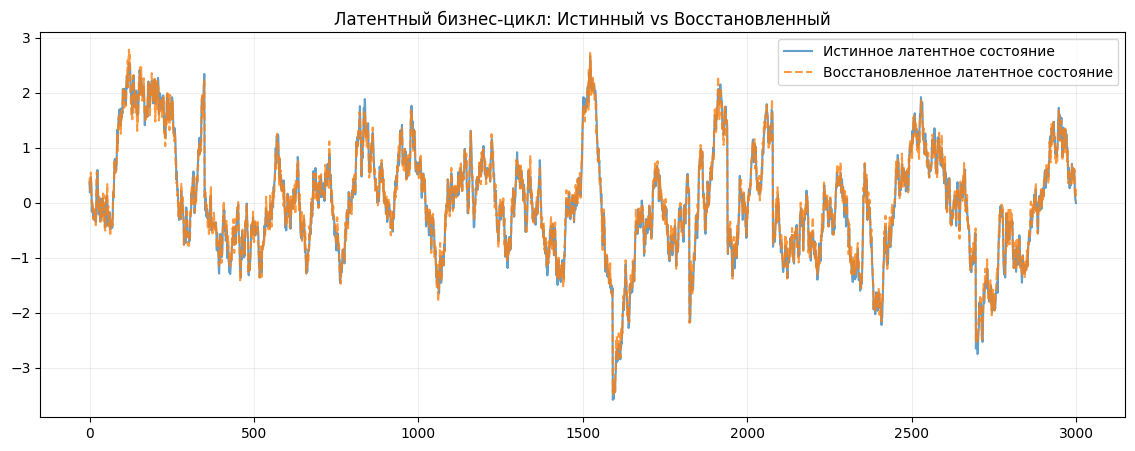

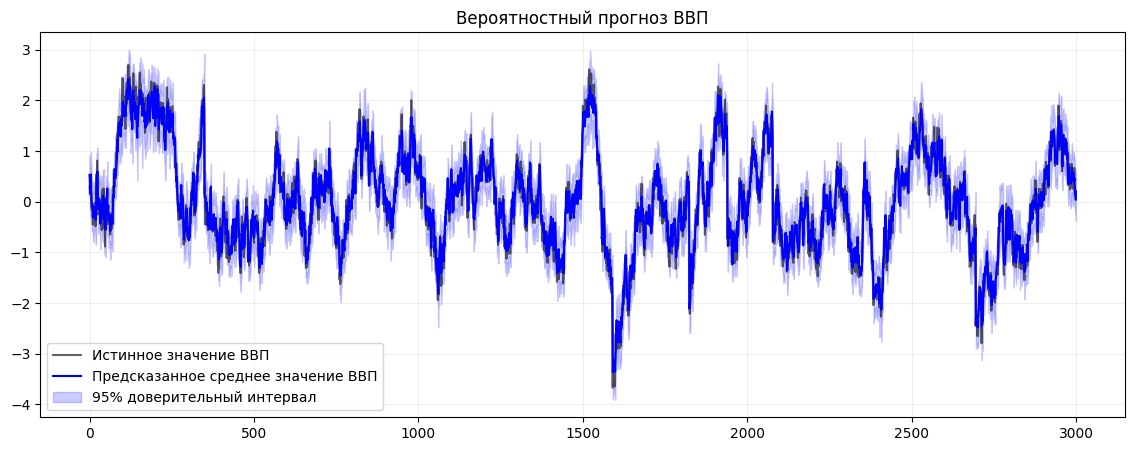

In [49]:
# ============================================================
# Графики
# ============================================================

# Проверка наличия необходимых переменных перед построением
if 'z_est' in locals() and 'pred_mu' in locals():
    # График 1: Сравнение истинного и восстановленного латентного состояния
    plt.figure(figsize=(14,5))
    plt.plot(Z, label='Истинное латентное состояние', alpha=0.7)
    plt.plot(z_est, label='Восстановленное латентное состояние', alpha=0.8, linestyle='--')
    plt.legend()
    plt.title('Латентный бизнес-цикл: Истинный vs Восстановленный')
    plt.grid(True, alpha=0.2)
    plt.show()

    # График 2: Вероятностный прогноз ВВП
    plt.figure(figsize=(14,5))
    t_axis = np.arange(len(Y))
    plt.plot(t_axis, Y, label='Истинное значение ВВП', color='black', alpha=0.6)
    plt.plot(t_axis, pred_mu, label='Предсказанное среднее значение ВВП', color='blue')

    # Отрисовка доверительного интервала 95%
    plt.fill_between(
        t_axis,
        pred_mu - 2*pred_sigma,
        pred_mu + 2*pred_sigma,
        color='blue',
        alpha=0.2,
        label='95% доверительный интервал'
    )

    plt.legend()
    plt.title('Вероятностный прогноз ВВП')
    plt.grid(True, alpha=0.2)
    plt.show()
else:
    print("Ошибка. Запустите ячейку вывода")

In [50]:
# ============================================================
# Количественная оценка
# ============================================================

from scipy.stats import pearsonr
from sklearn.metrics import mean_squared_error

# Расчет корреляции для латентного цикла
corr_z, _ = pearsonr(Z, z_est)
mse_z = mean_squared_error(Z, z_est)

# Расчет метрик для прогноза ВВП
corr_y, _ = pearsonr(Y, pred_mu)
mse_y = mean_squared_error(Y, pred_mu)

print(f"--- Восстановление латентного состояния ---")
print(f"Корреляция (Истинный vs Оцененный Z): {corr_z:.4f}")
print(f"MSE Z: {mse_z:.4f}")

print(f"\n--- Эффективность прогноза ВВП ---")
print(f"Корреляция (Истинный vs Предсказанный Y): {corr_y:.4f}")
print(f"MSE Y: {mse_y:.4f}")

--- Восстановление латентного состояния ---
Корреляция (Истинный vs Оцененный Z): 0.9934
MSE Z: 0.0139

--- Эффективность прогноза ВВП ---
Корреляция (Истинный vs Предсказанный Y): 0.9706
MSE Y: 0.0587


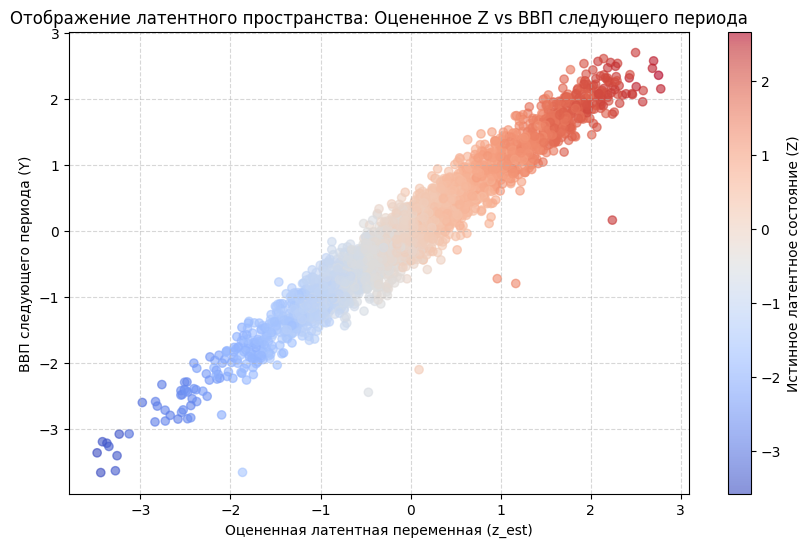

Данный график показывает, как извлеченная латентная переменная коррелирует с будущим ВВП.
Четкая диагональная структура подтверждает, что модель успешно выделила макроэкономический цикл.


In [51]:
# ============================================================
# Анализ латентного пространства
# ============================================================

plt.figure(figsize=(10, 6))

# Красим точки по значениям Z
scatter = plt.scatter(z_est, Y, c=Z, cmap='coolwarm', alpha=0.6)
plt.colorbar(scatter, label='Истинное латентное состояние (Z)')

plt.xlabel('Оцененная латентная переменная (z_est)')
plt.ylabel('ВВП следующего периода (Y)')
plt.title('Отображение латентного пространства: Оцененное Z vs ВВП следующего периода')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

print("Данный график показывает, как извлеченная латентная переменная коррелирует с будущим ВВП.")
print("Четкая диагональная структура подтверждает, что модель успешно выделила макроэкономический цикл.")

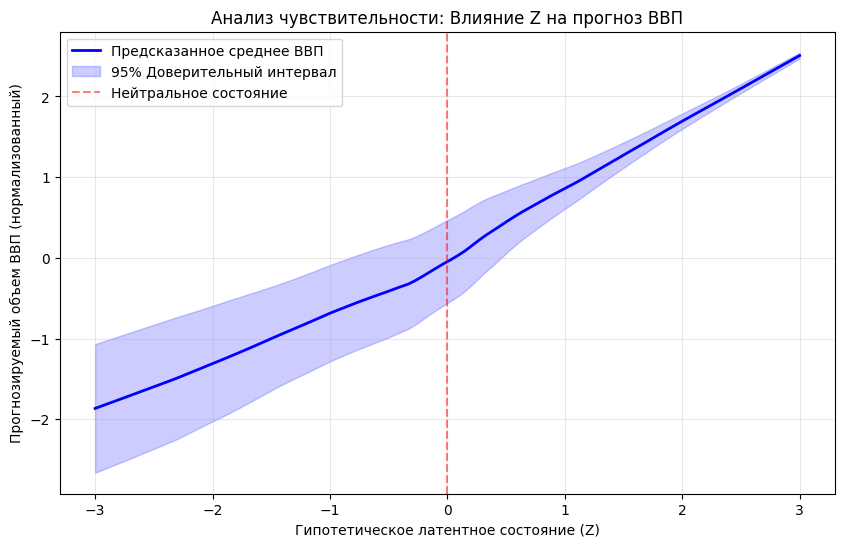

Этот график показывает 'чистую' зависимость ВВП от бизнес-цикла внутри модели.


In [52]:
# ============================================================
# Анализ чувствительности
# ============================================================

# Генерируем диапазон возможных состояний латентного цикла
z_range = torch.linspace(-3, 3, 100).view(-1, 1)

# Берем среднее состояние входных данных (X) для фиксации контекста
x_context = X_t.mean(0, keepdim=True).repeat(100, 1)

model.eval()
with torch.no_grad():
    # Прогнозируем ВВП на основе искусственных значений Z
    mu_scenario, sigma_scenario = model.predict(z_range, x_context)

mu_scenario = mu_scenario.numpy().flatten()
sigma_scenario = sigma_scenario.numpy().flatten()
z_axis = z_range.numpy().flatten()

plt.figure(figsize=(10, 6))
plt.plot(z_axis, mu_scenario, label='Предсказанное среднее ВВП', color='blue', lw=2)
plt.fill_between(z_axis, mu_scenario - 2*sigma_scenario, mu_scenario + 2*sigma_scenario,
                 color='blue', alpha=0.2, label='95% Доверительный интервал')

plt.axvline(0, color='red', linestyle='--', alpha=0.5, label='Нейтральное состояние')
plt.xlabel('Гипотетическое латентное состояние (Z)')
plt.ylabel('Прогнозируемый объем ВВП (нормализованный)')
plt.title('Анализ чувствительности: Влияние Z на прогноз ВВП')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("Этот график показывает 'чистую' зависимость ВВП от бизнес-цикла внутри модели.")